# Digital Image Processing – Lab 5
## Intensity Transformation II (Histogram Processing)

Name: ____________________  
Student ID: ________________  
Date: ______________________


# Task 1 – Histogram Equalization (Grayscale Image)

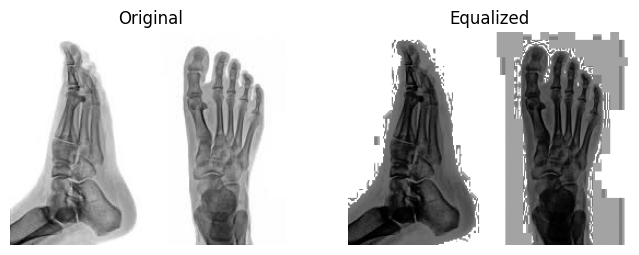

In [9]:
import cv2
import matplotlib.pyplot as plt

image = cv2.imread('foot.jpg', 0)

if image is None:
    print("Image not found. Check file name!")
else:
    equalized = cv2.equalizeHist(image)

    plt.figure(figsize=(8,4))

    plt.subplot(1,2,1)
    plt.imshow(image, cmap='gray')
    plt.title("Original")
    plt.axis('off')

    plt.subplot(1,2,2)
    plt.imshow(equalized, cmap='gray')
    plt.title("Equalized")
    plt.axis('off')

    plt.show()


# Task 2 – Histogram Equalization (Color Image)

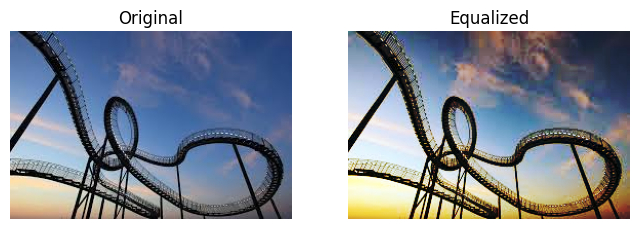

In [13]:
import cv2
import matplotlib.pyplot as plt

image = cv2.imread('im.jpg')

if image is None:
    print("Image not found!")
else:
    b,g,r = cv2.split(image)

    b_eq = cv2.equalizeHist(b)
    g_eq = cv2.equalizeHist(g)
    r_eq = cv2.equalizeHist(r)

    result = cv2.merge((b_eq, g_eq, r_eq))

    plt.figure(figsize=(8,4))

    plt.subplot(1,2,1)
    plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    plt.title("Original")
    plt.axis('off')

    plt.subplot(1,2,2)
    plt.imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))
    plt.title("Equalized")
    plt.axis('off')

    plt.show()


# Task 3 – Histogram Matching

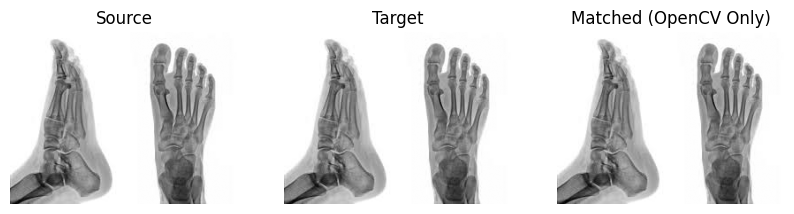

In [16]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def histogram_matching(source, target):

    # Compute histograms
    hist_source, bins = np.histogram(source.flatten(), 256, [0,256])
    hist_target, bins = np.histogram(target.flatten(), 256, [0,256])

    # Compute CDF
    cdf_source = hist_source.cumsum()
    cdf_target = hist_target.cumsum()

    # Normalize
    cdf_source = cdf_source / cdf_source.max()
    cdf_target = cdf_target / cdf_target.max()

    # Create lookup table
    lookup = np.zeros(256)
    for i in range(256):
        diff = np.abs(cdf_source[i] - cdf_target)
        lookup[i] = np.argmin(diff)

    # Apply mapping
    matched = cv2.LUT(source, lookup.astype('uint8'))

    return matched


source = cv2.imread('foot.jpg', 0)
target = cv2.imread('foot.jpg', 0)

if source is None or target is None:
    print("Check image names!")
else:
    matched = histogram_matching(source, target)

    plt.figure(figsize=(10,4))

    plt.subplot(1,3,1)
    plt.imshow(source, cmap='gray')
    plt.title("Source")
    plt.axis('off')

    plt.subplot(1,3,2)
    plt.imshow(target, cmap='gray')
    plt.title("Target")
    plt.axis('off')

    plt.subplot(1,3,3)
    plt.imshow(matched, cmap='gray')
    plt.title("Matched (OpenCV Only)")
    plt.axis('off')

    plt.show()


# Task 4 – Equalization Followed by Matching

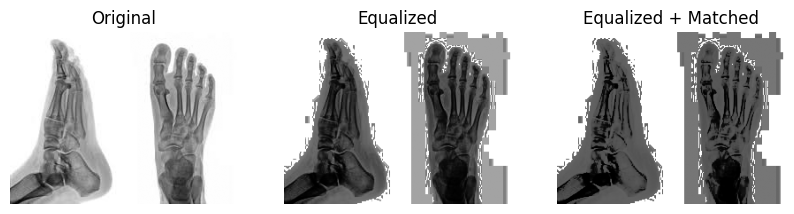

In [12]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def histogram_matching(source, target):

    hist_source, _ = np.histogram(source.flatten(), 256, [0,256])
    hist_target, _ = np.histogram(target.flatten(), 256, [0,256])

    cdf_source = hist_source.cumsum()
    cdf_target = hist_target.cumsum()

    cdf_source = cdf_source / cdf_source.max()
    cdf_target = cdf_target / cdf_target.max()

    lookup = np.zeros(256)
    for i in range(256):
        lookup[i] = np.argmin(np.abs(cdf_source[i] - cdf_target))

    matched = cv2.LUT(source, lookup.astype('uint8'))
    return matched


source = cv2.imread('foot.jpg', 0)
target = cv2.imread('im.jpg', 0)

equalized = cv2.equalizeHist(source)
final = histogram_matching(equalized, target)

plt.figure(figsize=(10,4))

plt.subplot(1,3,1)
plt.imshow(source, cmap='gray')
plt.title("Original")
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(equalized, cmap='gray')
plt.title("Equalized")
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(final, cmap='gray')
plt.title("Equalized + Matched")
plt.axis('off')

plt.show()
